In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# ==========================================================
# Oscillateur harmonique quantique 1D
# ==========================================================
# Hamiltonien :
#
# H = p²/2m + 1/2 mω²x²
#
# Ici on le discrétise sur une grille spatiale.
# ==========================================================

In [9]:
# -----------------------------
# Paramètres physiques
# -----------------------------

hbar = 1.0
m = 1.0
omega = 1.0

In [10]:
# -----------------------------
# Grille spatiale
# -----------------------------

N = 120
xmax = 5

x = np.linspace(-xmax, xmax, N)
dx = x[1] - x[0]

In [11]:
# -----------------------------
# Potentiel harmonique
# -----------------------------

V = 0.5 * m * omega**2 * x**2

In [12]:
# -----------------------------
# Opérateur cinétique
# Approximation différences finies
# -----------------------------

diag = np.ones(N)

T = (-hbar**2 / (2*m*dx**2)) * (
    np.diag(-2*diag) +
    np.diag(diag[:-1], 1) +
    np.diag(diag[:-1], -1)
)

In [13]:
# -----------------------------
# Hamiltonien total
# -----------------------------

H = T + np.diag(V)

In [14]:
# -----------------------------
# Diagonalisation
# -----------------------------

eigenvalues, eigenvectors = np.linalg.eigh(H)

C:\Users\g.melis\AppData\Local\Temp\ipykernel_21920\1389074169.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


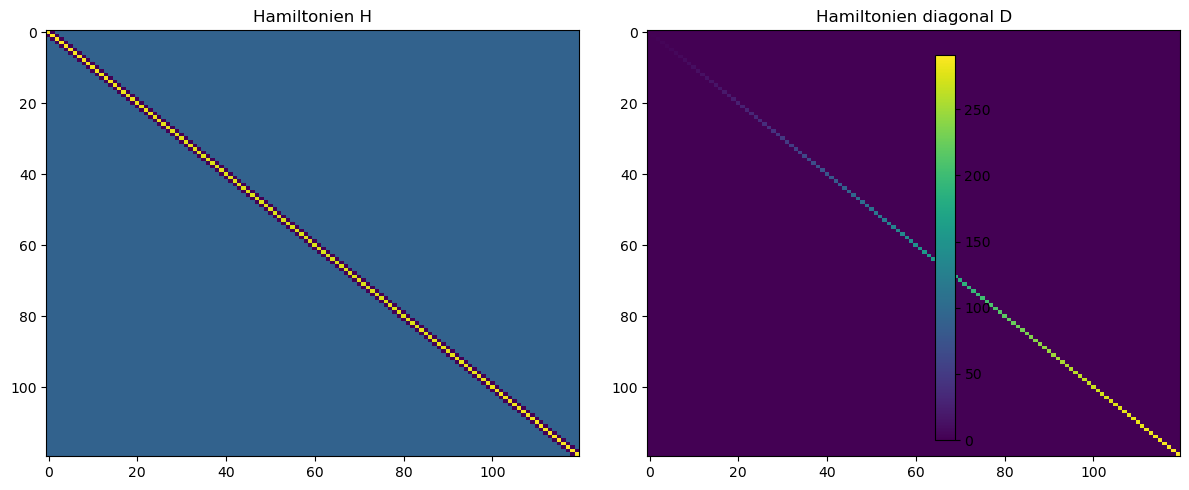

In [15]:
# -----------------------------
# Heatmaps
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Hamiltonien
im0 = axes[0].imshow(H, aspect='auto')
axes[0].set_title("Hamiltonien H")

# Hamiltonien diagonal
D = np.diag(eigenvalues)

im1 = axes[1].imshow(D, aspect='auto')
axes[1].set_title("Hamiltonien diagonal D")

plt.colorbar(im1, ax=axes.ravel().tolist())
plt.tight_layout()
plt.show()

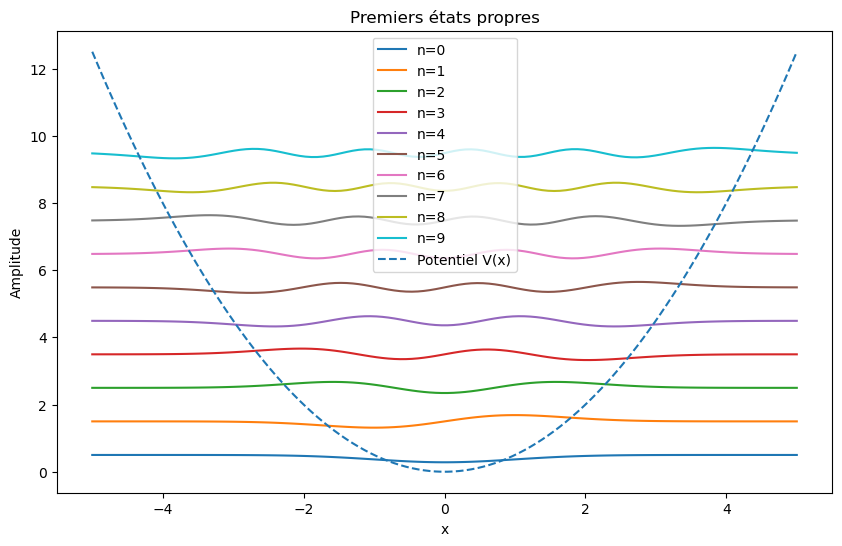

In [24]:
# -----------------------------
# Affichage des états propres
# -----------------------------

plt.figure(figsize=(10,6))

for n in range(10):
    psi = eigenvectors[:, n]
    plt.plot(x, psi + eigenvalues[n],
             label=f"n={n}")

plt.plot(x, V, '--', label="Potentiel V(x)")

plt.title("Premiers états propres")
plt.xlabel("x")
plt.ylabel("Amplitude")

plt.legend()
plt.show()

In [17]:
# -----------------------------
# Valeurs propres
# -----------------------------

print("Premières énergies :")
print(eigenvalues[:10])

Premières énergies :
[0.49977923 1.49889574 2.49712783 3.4944748  4.49094021 5.48655709
 6.48151439 7.4766329  8.47467034 9.48271487]
